In [1]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("spam.csv", encoding="latin-1")

In [4]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5572
Number of columns: 2


In [6]:
df.columns

Index(['Category', 'Message'], dtype='object')

In [7]:
df = df[['Category', 'Message']]

In [8]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [10]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Category    0
Message     0
dtype: int64


In [11]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 415


In [12]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (5157, 2)


In [13]:
print(df['Category'].unique())

['ham' 'spam']


In [14]:
print(df['Category'].value_counts())

Category
ham     4516
spam     641
Name: count, dtype: int64


In [15]:
print(df['Category'].value_counts(normalize=True) * 100)

Category
ham     87.570293
spam    12.429707
Name: proportion, dtype: float64


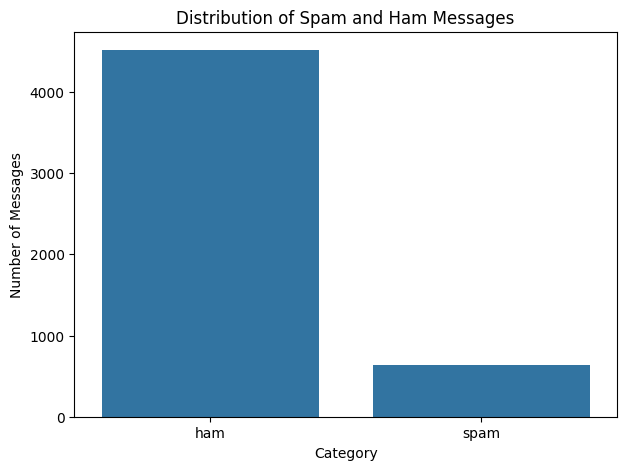

In [16]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Category')

plt.title('Distribution of Spam and Ham Messages')
plt.xlabel('Category')
plt.ylabel('Number of Messages')

plt.show()

In [ ]:
#The dataset contains two categories: spam and ham. Ham messages are more frequent than spam messages, indicating that the dataset is imbalanced.

In [17]:
df['message_length'] = df['Message'].apply(len)

df.head()

,Category,Message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [18]:
df['word_count'] = df['Message'].apply(lambda x: len(str(x).split()))

df.head()

,Category,Message,message_length,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13


In [19]:
df['char_count'] = df['Message'].apply(lambda x: len(str(x)))

df.head()

,Category,Message,message_length,word_count,char_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,111
1,ham,Ok lar... Joking wif u oni...,29,6,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,155
3,ham,U dun say so early hor... U c already then say...,49,11,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,61


In [20]:
df[['message_length', 'word_count']].describe()

,message_length,word_count
count,5157.000000,5157.000000
mean,79.228040,15.410704
std,58.451149,11.118902
min,2.000000,1.000000
25%,36.000000,7.000000
50%,61.000000,12.000000
75%,118.000000,22.000000
max,910.000000,171.000000


In [21]:
df.groupby('Category')['message_length'].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
ham,4516.0,70.951063,56.730031,2.0,34.0,53.0,91.0,910.0
spam,641.0,137.541342,30.516111,7.0,132.0,148.0,157.0,224.0


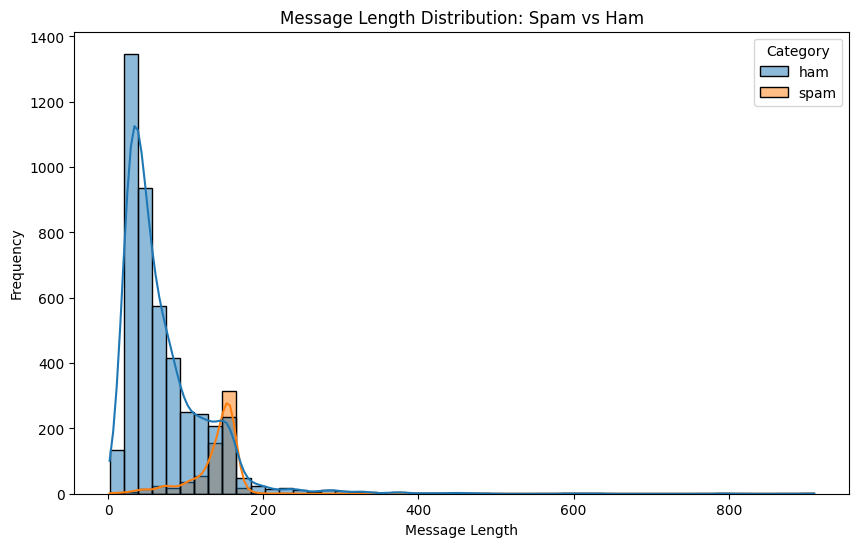

In [22]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='message_length',
    hue='Category',
    bins=50,
    kde=True
)

plt.title('Message Length Distribution: Spam vs Ham')
plt.xlabel('Message Length')
plt.ylabel('Frequency')

plt.show()

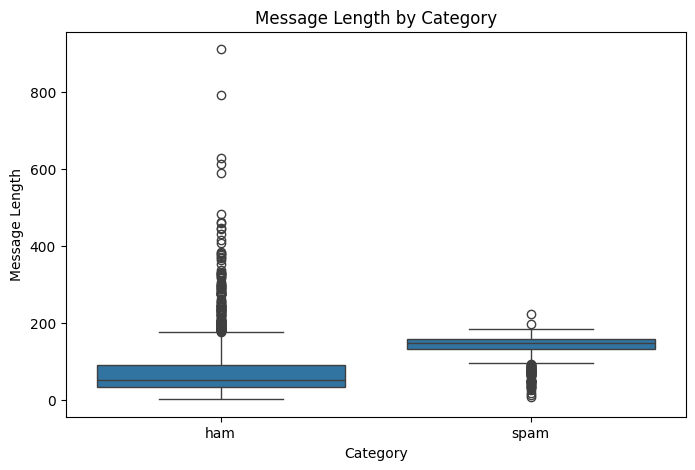

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Category',
    y='message_length'
)

plt.title('Message Length by Category')
plt.xlabel('Category')
plt.ylabel('Message Length')

plt.show()

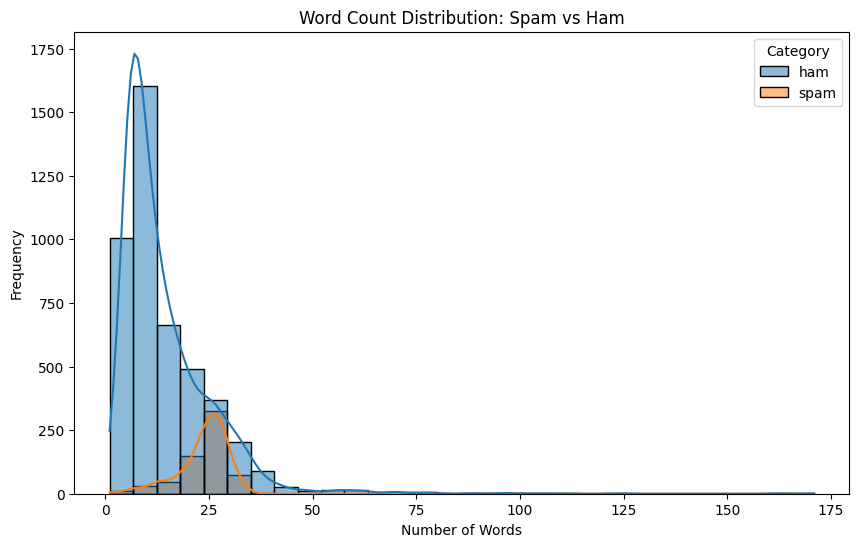

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='word_count',
    hue='Category',
    bins=30,
    kde=True
)

plt.title('Word Count Distribution: Spam vs Ham')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

plt.show()

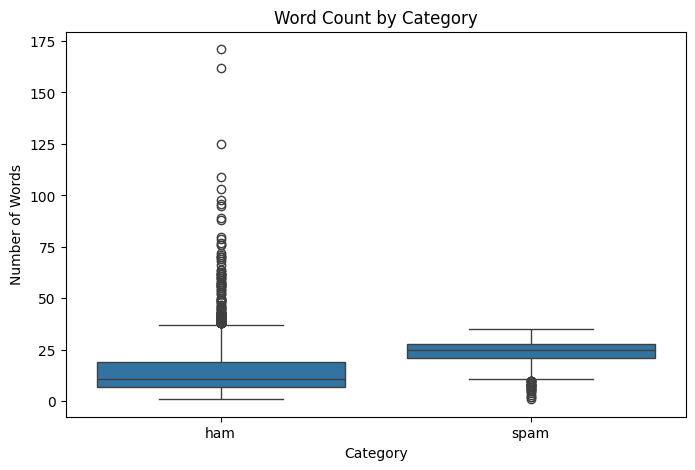

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Category',
    y='word_count'
)

plt.title('Word Count by Category')
plt.xlabel('Category')
plt.ylabel('Number of Words')

plt.show()

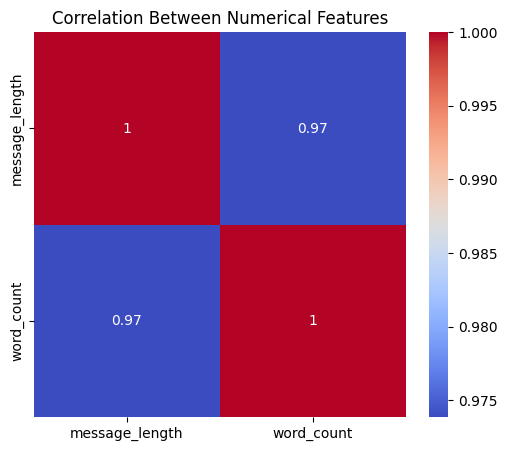

In [26]:
numeric_columns = df[['message_length', 'word_count']]

plt.figure(figsize=(6,5))

sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Between Numerical Features')

plt.show()

In [27]:
df.sort_values(
    by='message_length',
    ascending=False
)[['Category', 'Message', 'message_length']].head(10)

,Category,Message,message_length
1085,ham,For me the love should start with attraction.i...,910
1863,ham,The last thing i ever wanted to do was hurt yo...,790
2434,ham,Indians r poor but India is not a poor country...,629
1579,ham,How to Make a girl Happy? It's not at all diff...,611
2158,ham,Sad story of a Man - Last week was my b'day. M...,588
2380,ham,"Good evening Sir, hope you are having a nice d...",482
3017,ham,"&lt;#&gt; is fast approaching. So, Wish u a v...",461
1513,ham,"Hey sweet, I was wondering when you had a mome...",458
2370,ham,A Boy loved a gal. He propsd bt she didnt mind...,446
2408,ham,Solve d Case : A Man Was Found Murdered On &l...,444


In [28]:
df.sort_values(
    by='message_length',
    ascending=True
)[['Category', 'Message', 'message_length']].head(10)

,Category,Message,message_length
3376,ham,:),2
1925,ham,Ok,2
1612,ham,645,3
2182,ham,Ok.,3
261,ham,Yup,3
2602,ham,Okie,4
287,ham,Ok..,4
5173,ham,U 2.,4
1273,ham,Ok...,5
4293,ham,G.W.R,5


In [29]:
import re
from collections import Counter

In [30]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    return words

In [31]:
spam_messages = df[df['Category'] == 'spam']['Message']

spam_words = []

for message in spam_messages:
    spam_words.extend(clean_text(message))

spam_word_counts = Counter(spam_words)

spam_word_counts.most_common(20)

[('to', 580),
 ('a', 326),
 ('call', 297),
 ('you', 248),
 ('your', 236),
 ('free', 185),
 ('for', 182),
 ('the', 177),
 ('or', 156),
 ('now', 155),
 ('is', 138),
 ('u', 127),
 ('txt', 125),
 ('on', 121),
 ('ur', 119),
 ('from', 118),
 ('have', 111),
 ('stop', 108),
 ('text', 104),
 ('and', 104)]

In [32]:
ham_messages = df[df['Category'] == 'ham']['Message']

ham_words = []

for message in ham_messages:
    ham_words.extend(clean_text(message))

ham_word_counts = Counter(ham_words)

ham_word_counts.most_common(20)

[('i', 2083),
 ('you', 1777),
 ('to', 1481),
 ('the', 1059),
 ('a', 973),
 ('u', 903),
 ('and', 819),
 ('in', 757),
 ('me', 717),
 ('my', 673),
 ('is', 652),
 ('it', 549),
 ('for', 481),
 ('of', 478),
 ('that', 474),
 ('im', 448),
 ('have', 424),
 ('but', 406),
 ('so', 400),
 ('are', 393)]

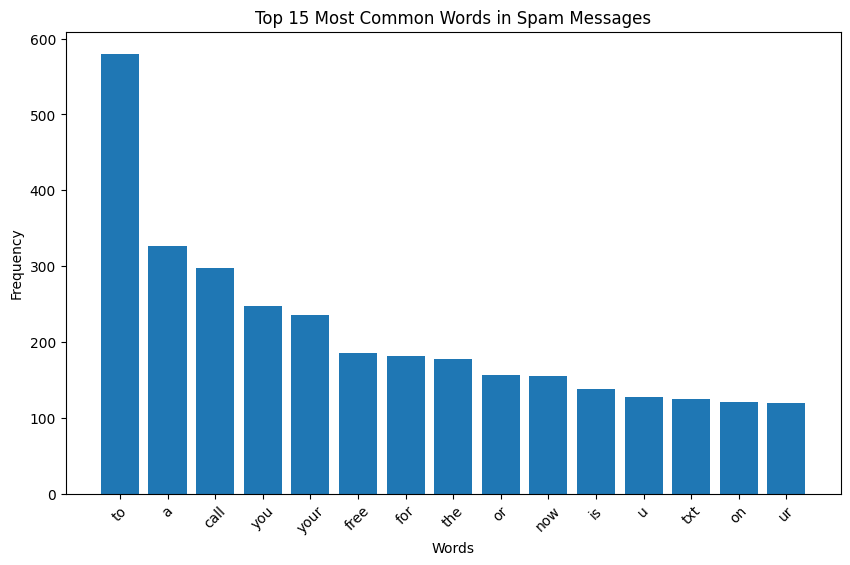

In [33]:
spam_common = spam_word_counts.most_common(15)

words = [x[0] for x in spam_common]
counts = [x[1] for x in spam_common]

plt.figure(figsize=(10,6))

plt.bar(words, counts)

plt.title('Top 15 Most Common Words in Spam Messages')
plt.xlabel('Words')
plt.ylabel('Frequency')

plt.xticks(rotation=45)

plt.show()

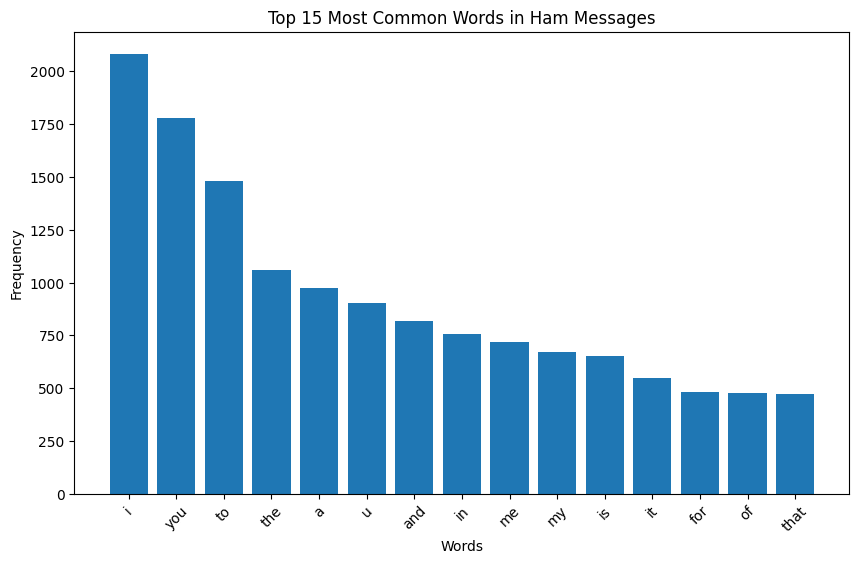

In [34]:
ham_common = ham_word_counts.most_common(15)

words = [x[0] for x in ham_common]
counts = [x[1] for x in ham_common]

plt.figure(figsize=(10,6))

plt.bar(words, counts)

plt.title('Top 15 Most Common Words in Ham Messages')
plt.xlabel('Words')
plt.ylabel('Frequency')

plt.xticks(rotation=45)

plt.show()

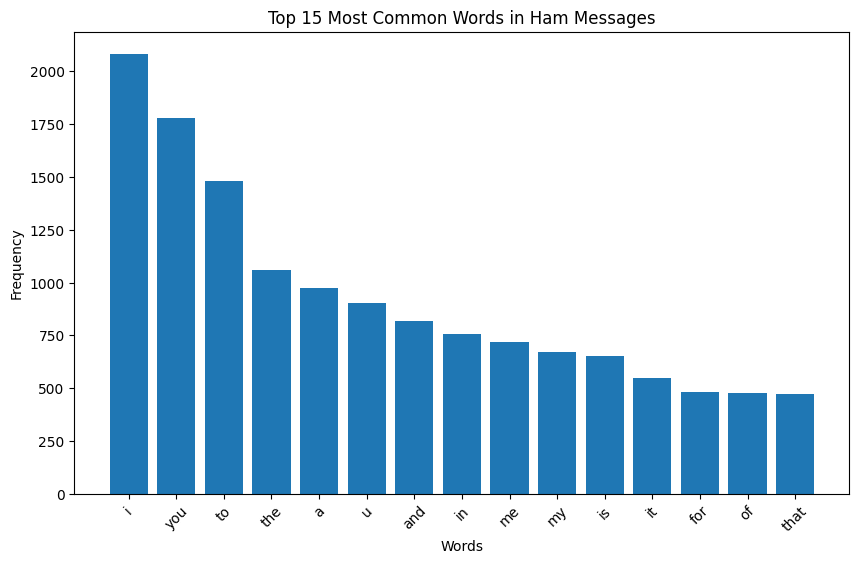

In [35]:
ham_common = ham_word_counts.most_common(15)

words = [x[0] for x in ham_common]
counts = [x[1] for x in ham_common]

plt.figure(figsize=(10,6))

plt.bar(words, counts)

plt.title('Top 15 Most Common Words in Ham Messages')
plt.xlabel('Words')
plt.ylabel('Frequency')

plt.xticks(rotation=45)

plt.show()

In [36]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [37]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

In [38]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [39]:
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters and punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words
    return ' '.join(words)

In [40]:
sample_message = df['Message'].iloc[0]

print("Original Message:")
print(sample_message)

print("\nProcessed Message:")
print(preprocess_text(sample_message))

Original Message:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Processed Message:
go jurong point crazy available bugis n great world la e buffet cine got amore wat


In [41]:
df['clean_message'] = df['Message'].apply(preprocess_text)

In [42]:
df[['Message', 'clean_message']].head(10)

,Message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling week word back id like fun...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile month u r entitled update latest colour...


In [43]:
df = df[df['clean_message'].str.strip() != '']

print("Dataset shape:", df.shape)

Dataset shape: (5151, 6)


In [44]:
df['label'] = df['Category'].map({
    'ham': 0,
    'spam': 1
})

In [45]:
df[['Category', 'label']].head(10)

,Category,label
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0
5,spam,1
6,ham,0
7,ham,0
8,spam,1
9,spam,1


In [46]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

label
0    4510
1     641
Name: count, dtype: int64
label
0    87.555814
1    12.444186
Name: proportion, dtype: float64


In [49]:
X = df['clean_message']
y = df['label']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4120
Testing samples: 1031


In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)
feature_names = tfidf.get_feature_names_out()

print("Number of features:", len(feature_names))

print("\nFirst 50 features:")
print(feature_names[:50])
print(X_train_tfidf[0].toarray())
print("Original:")
print(df['Message'].iloc[0])

print("\nCleaned:")
print(df['clean_message'].iloc[0])

print("\nLabel:")
print(df['label'].iloc[0])
df.to_csv(
    "spam_ham_processed.csv",
    index=False
)

print("Processed dataset saved successfully.")

Training TF-IDF shape: (4120, 5000)
Testing TF-IDF shape: (1031, 5000)
Number of features: 5000

First 50 features:
['aah' 'abi' 'abiola' 'abj' 'able' 'able come' 'able deliver' 'abt' 'ac'
 'acc' 'accept' 'access' 'accidentally' 'account' 'account statement'
 'ache' 'across' 'across sea' 'action' 'activate' 'actually' 'ad' 'add'
 'added' 'address' 'admirer' 'admirer looking' 'adult' 'advance' 'advice'
 'affair' 'aft' 'aft ur' 'afternoon' 'afternoon love' 'aftr' 'age' 'ago'
 'ah' 'aha' 'ahead' 'ahmad' 'aight' 'aight ill' 'aint' 'air' 'airport'
 'aiya' 'aiyah' 'aiyar']
[[0. 0. 0. ... 0. 0. 0.]]
Original:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Cleaned:
go jurong point crazy available bugis n great world la e buffet cine got amore wat

Label:
0
Processed dataset saved successfully.


In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}
trained_models = {}

for name, model in models.items():

    model.fit(X_train_tfidf, y_train)

    trained_models[name] = model

    print(name, "trained successfully")
    predictions = {}

for name, model in trained_models.items():

    y_pred = model.predict(X_test_tfidf)

    predictions[name] = y_pred
    from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, y_pred in predictions.items():

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df
results_df[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
] = results_df[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
] * 100

results_df
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions["SVM"],
        target_names=["Ham", "Spam"]
    )
)

Logistic Regression trained successfully
Naive Bayes trained successfully
SVM trained successfully
Random Forest trained successfully
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       903
        Spam       0.98      0.92      0.95       128

    accuracy                           0.99      1031
   macro avg       0.98      0.96      0.97      1031
weighted avg       0.99      0.99      0.99      1031



In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get SVM predictions
y_pred_svm = predictions["SVM"]

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[900   3]
 [ 10 118]]


<Figure size 600x500 with 0 Axes>

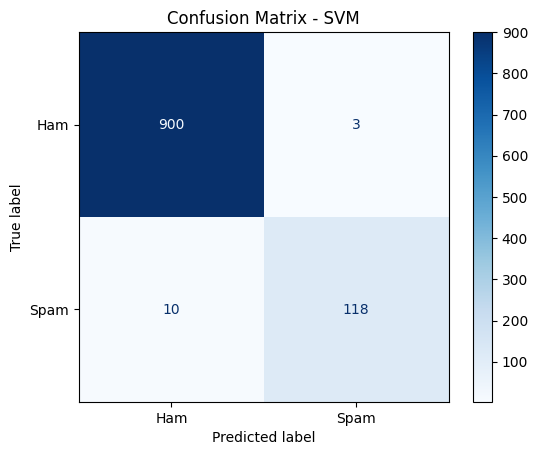

In [53]:
plt.figure(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - SVM")
plt.show()

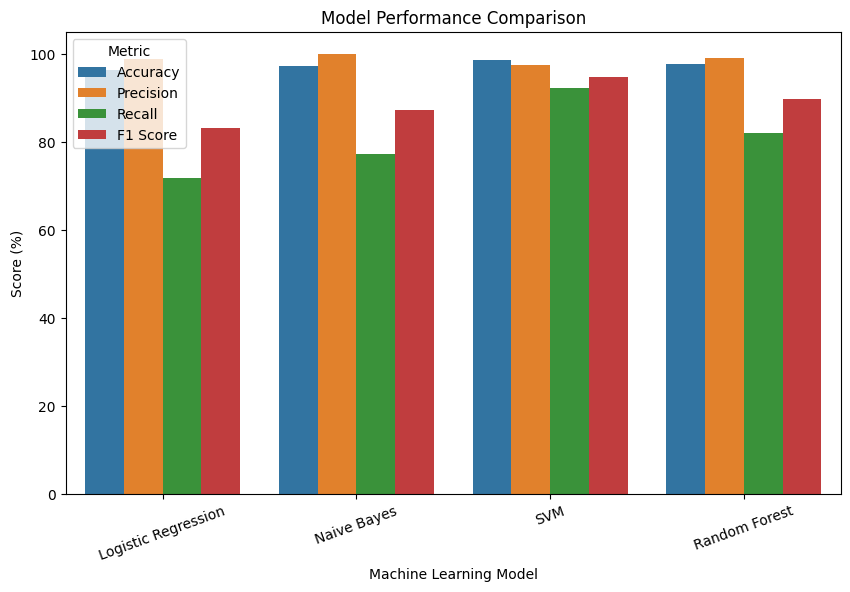

In [54]:
results_df
plt.figure(figsize=(10,6))

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score (%)")

plt.xticks(rotation=20)
plt.legend(title="Metric")

plt.show()

In [55]:
for name, y_pred in predictions.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Ham", "Spam"]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.72      0.83       128

    accuracy                           0.96      1031
   macro avg       0.98      0.86      0.91      1031
weighted avg       0.97      0.96      0.96      1031

Naive Bayes
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       903
        Spam       1.00      0.77      0.87       128

    accuracy                           0.97      1031
   macro avg       0.98      0.89      0.93      1031
weighted avg       0.97      0.97      0.97      1031

SVM
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       903
        Spam       0.98      0.92      0.95       128

    accuracy                           0.99      1031
   macro avg       0.98      0.96      0.97      1031
weighted avg       0.99      0.99     

In [56]:
final_model = trained_models["SVM"]

print("Final model selected: SVM")
def predict_message(message):

    # Preprocess the message
    cleaned_message = preprocess_text(message)

    # Convert text into TF-IDF
    message_tfidf = tfidf.transform([cleaned_message])

    # Predict
    prediction = final_model.predict(message_tfidf)[0]

    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"
        message = "Hey, are you coming to college tomorrow?"

result = predict_message(message)

print("Message:", message)
print("Prediction:", result)
message = "Congratulations! You have won a free prize. Call now to claim your reward!"

result = predict_message(message)

print("Message:", message)
print("Prediction:", result)
message = input("Enter your SMS message: ")

result = predict_message(message)

print("\nPrediction:", result)
test_messages = [
    "Hey, what are you doing?",
    "Congratulations! You won a lottery prize!",
    "Can you send me the assignment?",
    "URGENT! You have won 50000 rupees. Call now!",
    "Are we meeting at college tomorrow?"
]

for message in test_messages:
    prediction = predict_message(message)

    print("Message:", message)
    print("Prediction:", prediction)
    print("-" * 60)

Final model selected: SVM
Message: Rofl. Its true to its name
Prediction: HAM
Message: Congratulations! You have won a free prize. Call now to claim your reward!
Prediction: SPAM
Enter your SMS message: renuka

Prediction: HAM
Message: Hey, what are you doing?
Prediction: HAM
------------------------------------------------------------
Message: Congratulations! You won a lottery prize!
Prediction: SPAM
------------------------------------------------------------
Message: Can you send me the assignment?
Prediction: HAM
------------------------------------------------------------
Message: URGENT! You have won 50000 rupees. Call now!
Prediction: SPAM
------------------------------------------------------------
Message: Are we meeting at college tomorrow?
Prediction: HAM
------------------------------------------------------------


In [57]:
import joblib
joblib.dump(final_model, "spam_model.pkl")

joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully.")
import os

print("spam_model.pkl exists:",
      os.path.exists("spam_model.pkl"))

print("tfidf_vectorizer.pkl exists:",
      os.path.exists("tfidf_vectorizer.pkl"))
loaded_model = joblib.load("spam_model.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")

print("Model loaded successfully.")
print("Vectorizer loaded successfully.")
message = "Congratulations! You won a free mobile phone!"

cleaned = preprocess_text(message)

vector = loaded_tfidf.transform([cleaned])

prediction = loaded_model.predict(vector)[0]

if prediction == 1:
    print("Prediction: SPAM")
else:
    print("Prediction: HAM")

Model and vectorizer saved successfully.
spam_model.pkl exists: True
tfidf_vectorizer.pkl exists: True
Model loaded successfully.
Vectorizer loaded successfully.
Prediction: SPAM


In [58]:
import joblib

joblib.dump(final_model, "spam_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model saved successfully!")
print("Vectorizer saved successfully!")
import os

print(os.path.exists("spam_model.pkl"))
print(os.path.exists("tfidf_vectorizer.pkl"))

Model saved successfully!
Vectorizer saved successfully!
True
True


In [59]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 26.3 MB/s eta 0:00:00


In [60]:
%%writefile app.py

import streamlit as st
import joblib
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


# Download required NLTK resources
nltk.download("stopwords")
nltk.download("wordnet")


# --------------------------------------------------
# Load trained model and TF-IDF vectorizer
# --------------------------------------------------

model = joblib.load("spam_model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")


# --------------------------------------------------
# NLP preprocessing
# --------------------------------------------------

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenization
    words = text.split()

    # Stopword removal and lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)


# --------------------------------------------------
# Streamlit page configuration
# --------------------------------------------------

st.set_page_config(
    page_title="Spam & Ham Detector",
    page_icon="📱",
    layout="centered"
)


# --------------------------------------------------
# Application title
# --------------------------------------------------

st.title("📱 Spam & Ham Message Detector")

st.write(
    "Enter an SMS message below to determine whether "
    "it is Spam or Ham."
)


# --------------------------------------------------
# Message input
# --------------------------------------------------

message = st.text_area(
    "Enter your message:",
    height=150,
    placeholder="Example: Congratulations! You have won a prize!"
)


# --------------------------------------------------
# Prediction
# --------------------------------------------------

if st.button("🔍 Predict"):

    if message.strip() == "":
        st.warning("Please enter a message.")

    else:

        cleaned_message = preprocess_text(message)

        message_vector = tfidf.transform(
            [cleaned_message]
        )

        prediction = model.predict(
            message_vector
        )[0]

        if prediction == 1:
            st.error("🚨 SPAM MESSAGE")

        else:
            st.success("✅ HAM MESSAGE")


# --------------------------------------------------
# Footer
# --------------------------------------------------

st.markdown("---")

st.caption(
    "Spam & Ham Classification using NLP and SVM"
)

Writing app.py


In [61]:
!python -m py_compile app.py

print("app.py syntax is correct!")

app.py syntax is correct!


In [63]:
import os

print(os.listdir())

['.config', 'spam_ham_processed.csv', 'spam_model.pkl', '__pycache__', 'spam_ham_deployment.zip', 'app.py', 'spam.csv', 'tfidf_vectorizer.pkl', 'sample_data']


In [64]:
%%writefile requirements.txt

streamlit
scikit-learn
pandas
numpy
nltk
joblib

Writing requirements.txt


In [65]:
import os

print("requirements.txt exists:",
      os.path.exists("requirements.txt"))

requirements.txt exists: True


In [66]:
required_files = [
    "app.py",
    "requirements.txt",
    "spam_model.pkl",
    "tfidf_vectorizer.pkl"
]

for file in required_files:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file, "NOT FOUND")

✅ app.py
✅ requirements.txt
✅ spam_model.pkl
✅ tfidf_vectorizer.pkl


In [67]:
import zipfile
import os

files_to_zip = [
    "app.py",
    "requirements.txt",
    "spam_model.pkl",
    "tfidf_vectorizer.pkl"
]

with zipfile.ZipFile(
    "spam_ham_deployment.zip",
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for file in files_to_zip:
        zipf.write(file)

print("✅ Deployment ZIP created successfully!")

✅ Deployment ZIP created successfully!


In [68]:
from google.colab import files

files.download("spam_ham_deployment.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>